In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [ ]:
df = pd.read_csv("data/cars_fuel_efficiency.csv")
df.head()

,model,year,cylinders,engine_litres,power_hp,mass_kg,accel_0_100_s,region,fuel_efficiency_km_per_l
0,chevrolet chevelle malibu,1970,8,5.03,130.0,1589.0,12.0,USA,7.65
1,buick skylark 320,1970,8,5.74,165.0,1675.0,11.5,USA,6.38
2,plymouth satellite,1970,8,5.21,150.0,1559.0,11.0,USA,7.65
3,amc rebel sst,1970,8,4.98,150.0,1557.0,12.0,USA,6.80
4,ford torino,1970,8,4.95,140.0,1564.0,10.5,USA,7.23


In [8]:
print(df.shape)


(398, 9)


In [9]:
print(df.dtypes)

model                           str
year                          int64
cylinders                     int64
engine_litres               float64
power_hp                    float64
mass_kg                     float64
accel_0_100_s               float64
region                          str
fuel_efficiency_km_per_l    float64
dtype: object


In [10]:
df.describe()

,year,cylinders,engine_litres,power_hp,mass_kg,accel_0_100_s,fuel_efficiency_km_per_l
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,1976.010050,5.454774,3.169698,104.469388,1347.366834,15.568090,9.996834
std,3.697627,1.701004,1.708993,38.491160,384.123755,2.757689,3.322665
min,1970.000000,3.000000,1.110000,46.000000,732.000000,8.000000,3.830000
25%,1973.000000,4.000000,1.705000,75.000000,1008.500000,13.825000,7.440000
50%,1976.000000,4.000000,2.430000,93.500000,1271.500000,15.500000,9.780000
75%,1979.000000,8.000000,4.290000,126.000000,1636.500000,17.175000,12.330000
max,1982.000000,8.000000,7.460000,230.000000,2331.000000,24.800000,19.810000


In [11]:
df.isna().sum()

model                       0
year                        0
cylinders                   0
engine_litres               0
power_hp                    6
mass_kg                     0
accel_0_100_s               0
region                      0
fuel_efficiency_km_per_l    0
dtype: int64

In [ ]:
df = df.dropna(subset=["power_hp"])
print(df.shape)
print(df.isna().sum())

(392, 9)
model                       0
year                        0
cylinders                   0
engine_litres               0
power_hp                    0
mass_kg                     0
accel_0_100_s               0
region                      0
fuel_efficiency_km_per_l    0
dtype: int64


I removed 6 rows because power_hp contained missing values. This is only about 1.5% of the dataset, so removing them should not have a large effect on the analysis.

In [ ]:
numeric_df = df.select_dtypes(include="number")
correlations = numeric_df.corr()["fuel_efficiency_km_per_l"].sort_values()
print(correlations)

mass_kg                    -0.832189
engine_litres              -0.805146
power_hp                   -0.778400
cylinders                  -0.777538
accel_0_100_s               0.423319
year                        0.580628
fuel_efficiency_km_per_l    1.000000
Name: fuel_efficiency_km_per_l, dtype: float64


In [14]:
feature = "mass_kg"
target = "fuel_efficiency_km_per_l"

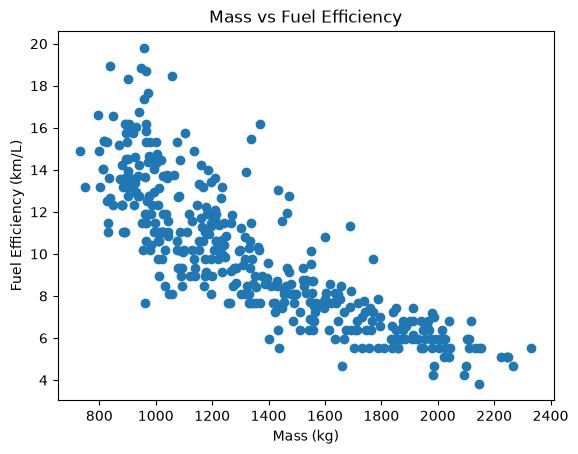

In [15]:
plt.scatter(df["mass_kg"], df["fuel_efficiency_km_per_l"])

plt.xlabel("Mass (kg)")
plt.ylabel("Fuel Efficiency (km/L)")
plt.title("Mass vs Fuel Efficiency")

plt.show()

In [ ]:
X = df[["mass_kg"]]
y = df["fuel_efficiency_km_per_l"]
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['mass_kg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,19.65
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
intercept = model.intercept_
slope = model.coef_[0]
print("Intercept:", intercept)
print("Slope:", slope)

Intercept: 19.64697849141596
Slope: -0.007166625872637475


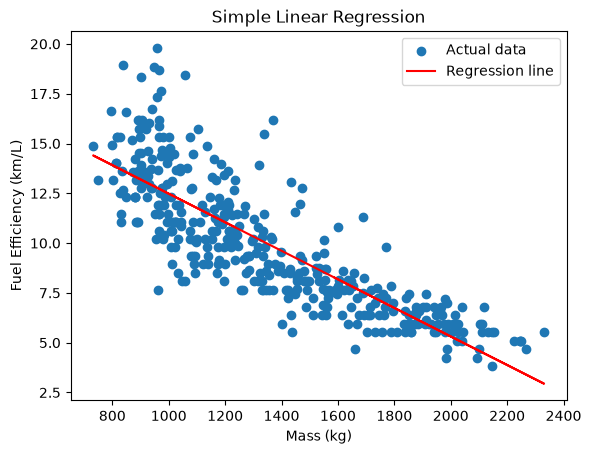

In [20]:
plt.scatter(
    df["mass_kg"],
    df["fuel_efficiency_km_per_l"],
    label="Actual data"
)

plt.plot(
    df["mass_kg"],
    model.predict(X),
    label="Regression line",
    color = 'red'
)

plt.xlabel("Mass (kg)")
plt.ylabel("Fuel Efficiency (km/L)")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

In [22]:
new_car = pd.DataFrame({"mass_kg": [4500]})
prediction = model.predict(new_car)
print(prediction)

[-12.60283794]


I selected mass because it has the strongest correlation with fuel efficiency, approximately -0.83. The negative correlation means that heavier cars usually have lower fuel efficiency. My fitted equation is approximately y = 19.65 - 0.00717x.

In [28]:
RANDOM_STATE = 1399 
X = df[["mass_kg"]]
y = df["fuel_efficiency_km_per_l"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (313, 1)
Test: (79, 1)


In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['mass_kg']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,19.53
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [26]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [27]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2
train_mae, train_mse, train_rmse, train_r2 = regression_metrics(
    y_train,
    y_train_pred
)

test_mae, test_mse, test_rmse, test_r2 = regression_metrics(
    y_test,
    y_test_pred
)
print("TRAIN")
print("MAE:", train_mae)
print("MSE:", train_mse)
print("RMSE:", train_rmse)
print("R2:", train_r2)

print()

print("TEST")
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R2:", test_r2)

TRAIN
MAE: 1.3633195099043887
MSE: 3.192876825111305
RMSE: 1.7868622848757274
R2: 0.6947994922385181

TEST
MAE: 1.4945830908897482
MSE: 4.11046614317384
RMSE: 2.0274284557472897
R2: 0.6801132961814111


Training performance alone is not enough because the model has already seen the training data. Test data shows how well the model can predict new, unseen cars.

In [30]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("R2 scores:", cv_scores)
print("Mean R2:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

R2 scores: [0.71197232 0.74606465 0.6805433  0.70310748 0.61577423]
Mean R2: 0.6914923968560936
Standard deviation: 0.04332572546635268


In [31]:
StandardScaler()
PolynomialFeatures()
poly_results = []

X_poly = df[["mass_kg"]]

for degree in range(1, 6):

    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),
        LinearRegression()
    )

    scores = cross_validate(
        pipe,
        X_poly,
        y,
        cv=kf,
        scoring="r2",
        return_train_score=True
    )

    poly_results.append({
        "Degree": degree,
        "Train R2": scores["train_score"].mean(),
        "Test R2": scores["test_score"].mean()
    })

poly_results = pd.DataFrame(poly_results)

poly_results

,Degree,Train R2,Test R2
0,1,0.692923,0.691492
1,2,0.715474,0.712928
2,3,0.715486,0.712840
3,4,0.715941,0.711927
4,5,0.716663,0.711539


In this lab, I used regression models to predict the fuel efficiency of cars. First, I checked the dataset and removed 6 rows with missing values in power_hp. Then I found that mass_kg had the strongest relationship with fuel efficiency. The relationship was negative, which means that heavier cars usually have lower fuel efficiency.
The simple linear regression model had a mean R² of about 0.6915 in 5-fold cross-validation, with a standard deviation of about 0.0433. This means that the model explains around 69% of the variation in fuel efficiency and gives relatively stable results across the folds.
I also tested polynomial regression with degrees from 1 to 5. The best test result was obtained with degree 2, with a test R² of about 0.7129. After degree 2, the training R² continued to increase slightly, but the test R² started to decrease. This shows that making the model more complex did not improve its performance on unseen data.
Based on these results, I would choose the degree 2 polynomial regression model because it gave the best test performance while remaining relatively simple.